In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
from IPython.display import display

In [3]:
import seaborn as sns
palette = sns.color_palette("tab10", n_colors=10)
palette

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

# Synthetic

In [31]:
df = pd.read_csv('mc_4states_p=0.9_1_27.csv')
df = df.fillna(value="none")
print(df.head())
df_full = df

   seed  nfe forward_process predictor_type corrector_type  num_steps gibbs_k  \
0     0   16  CosineSchedule            md4           none         16    none   
1     1   16  CosineSchedule            md4           none         16    none   
2     2   16  CosineSchedule            md4           none         16    none   
3     3   16  CosineSchedule            md4           none         16    none   
4     4   16  CosineSchedule            md4           none         16    none   

  gibbs_temperature  anneal_temperature maskgit_temperature  avg_run_length  \
0              none               False                none        6.827759   
1              none               False                none        6.799830   
2              none               False                none        6.780020   
3              none               False                none        6.885422   
4              none               False                none        6.730820   

   error_rate  
0    0.009039  
1    0

In [32]:
# Our two metrics are error_rate and avg_run_length
# We want to average metrics over the seed column, remove the seed column, and add the standard deviation columns for avg_run_length and error_rate
df_full

# The columns we want to group by are all columns except for the seed column and the two metrics columns
columns_to_group = [col for col in df_full.columns if col not in ['seed', 'error_rate', 'avg_run_length']]
df_full = df_full.groupby(columns_to_group).agg({'error_rate': ['mean', 'std'], 'avg_run_length': ['mean', 'std']}).reset_index()
df_full.columns = ['_'.join(filter(None, col)) for col in df_full.columns]

In [34]:
df = df_full
df[(df["predictor_type"] == 'md4') & (df["corrector_type"] == 'none')]

,nfe,forward_process,predictor_type,corrector_type,num_steps,gibbs_k,gibbs_temperature,anneal_temperature,maskgit_temperature,error_rate_mean,error_rate_std,avg_run_length_mean,avg_run_length_std
72,16,CosineSchedule,md4,none,16,none,none,False,none,0.009299,0.000183,6.804770,0.054035
145,16,LinearSchedule,md4,none,16,none,none,False,none,0.069844,0.000726,3.711411,0.015962
338,32,CosineSchedule,md4,none,32,none,none,False,none,0.004383,0.000075,7.918260,0.089002
411,32,LinearSchedule,md4,none,32,none,none,False,none,0.034931,0.000711,5.282535,0.050438
604,64,CosineSchedule,md4,none,64,none,none,False,none,0.002102,0.000048,8.711863,0.033035
677,64,LinearSchedule,md4,none,64,none,none,False,none,0.017444,0.000283,6.753977,0.046355
870,128,CosineSchedule,md4,none,128,none,none,False,none,0.001099,0.000067,9.068580,0.046257
943,128,LinearSchedule,md4,none,128,none,none,False,none,0.008742,0.000252,7.836591,0.080970


In [29]:
df_full.head()

,nfe,forward_process,predictor_type,corrector_type,num_steps,gibbs_k,gibbs_temperature,anneal_temperature,maskgit_temperature,error_rate_mean,error_rate_std,avg_run_length_mean,avg_run_length_std
0,16,CosineSchedule,maskgit,none,16,none,none,False,0.01,0.038586,0.000562,8.734558,0.048810
1,16,CosineSchedule,maskgit,none,16,none,none,False,0.1,0.032321,0.000477,10.437713,0.064662
2,16,CosineSchedule,maskgit,none,16,none,none,False,0.5,0.040153,0.000571,8.158764,0.053724
3,16,CosineSchedule,maskgit,none,16,none,none,False,1.0,0.045246,0.000379,6.441379,0.014315
4,16,CosineSchedule,maskgit,none,16,none,none,False,2.0,0.047764,0.000367,5.580572,0.021860


In [102]:
# Divide the data into 4 groups:
# 1. md4 predictor step, no corrector
# 2. maskgit predictor step, no corrector
# 3. md4 predictor step, gibbs corrector
# 4. md4 predictor step, gibbs_argmax corrector


def plot_metric(df, metric):
    # We want to take the configuration with the best metric for each group for each nfe value
    # In this case, the best metric is the lowest mean error rate
    df = df.sort_values(metric)
    columns_to_group = ['nfe', 'predictor_type', 'corrector_type']
    df = df.groupby(columns_to_group).first().reset_index()

    # Then for each group, we want to plot the error rate as a function of the number of nfes
    # We want to plot each group in a different color

    # We want to plot the error rate as a function of the number of p steps
    # We want to plot each group in a different color
    # Let's forget about the error bars

    for corrector in df['corrector_type'].unique():
        for predictor in df['predictor_type'].unique():
            df_subset = df[(df['corrector_type'] == corrector) & (df['predictor_type'] == predictor)]
            # if sebset is empty, skip
            if df_subset.empty:
                continue
            plt.plot(df_subset['nfe'], df_subset["error_rate_mean"], label=f'{predictor} predictor, {corrector} corrector')
            # plot the standard deviation as shaded area
            plt.fill_between(df_subset['nfe'], df_subset["error_rate_mean"] - df_subset["error_rate_std"],
                             df_subset["error_rate_mean"] + df_subset["error_rate_std"], alpha=0.3)

    plt.xlabel('Number of NFEs')
    plt.ylabel("error_rate")
    # plt.title('Influence of later entry time')
    plt.xscale('log')
    # plt.yscale('log')
    plt.xticks([16, 32, 64, 128])
    plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    plt.minorticks_off()
    plt.legend()
    plt.show()


    plt.figure()
    for corrector in df['corrector_type'].unique():
        for predictor in df['predictor_type'].unique():
            df_subset = df[(df['corrector_type'] == corrector) & (df['predictor_type'] == predictor)]
            # if sebset is empty, skip
            if df_subset.empty:
                continue
            plt.plot(df_subset['nfe'], df_subset["run_length_deviation"], label=f'{predictor} predictor, {corrector} corrector')

    plt.xlabel('Number of NFEs')
    plt.ylabel("run_length_deviation")
    # plt.title('Influence of later entry time')
    plt.xscale('log')
    plt.ylim(0, 20)
    plt.xticks([16, 32, 64, 128])
    plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    plt.minorticks_off()
    plt.legend()
    plt.show()

    return df


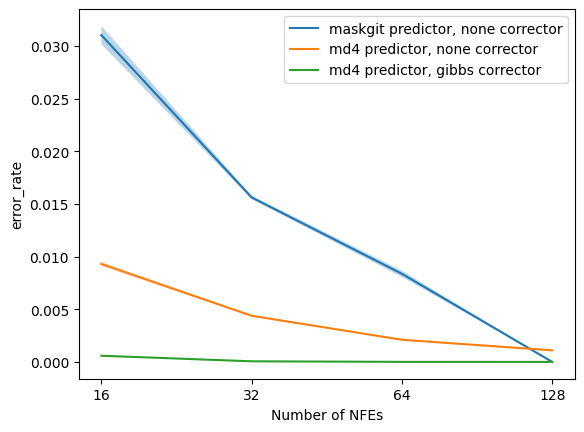

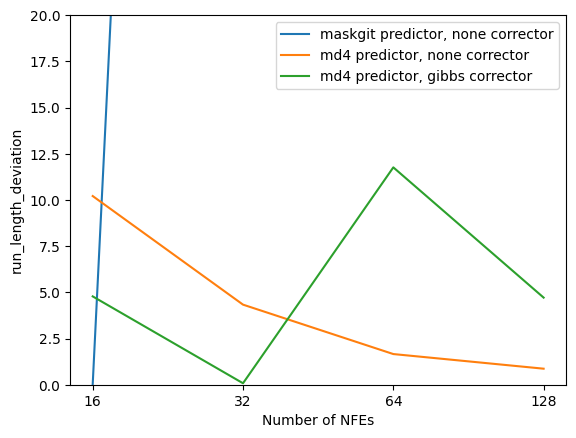

,nfe,predictor_type,corrector_type,forward_process,num_steps,gibbs_k,gibbs_temperature,anneal_temperature,maskgit_temperature,error_rate_mean,error_rate_std,avg_run_length_mean,avg_run_length_std,run_length_err,run_length_deviation,weighted_score
0,16,maskgit,none,CosineSchedule,16,none,none,True,0.5,0.031033,0.000868,10.172802,0.066454,0.029861,0.029861,0.031063
1,16,md4,gibbs,CosineSchedule,8,1.0,0.01,False,none,0.000587,0.000049,7.813837,0.118018,4.779310,4.779310,0.005367
2,16,md4,none,CosineSchedule,16,none,none,False,none,0.009299,0.000183,6.804770,0.054035,10.209494,10.209494,0.019509
3,32,maskgit,none,CosineSchedule,32,none,none,True,0.1,0.015619,0.000166,22.875361,0.174611,165.774931,165.774931,0.181394
4,32,md4,gibbs,CosineSchedule,16,1.0,2.0,False,none,0.000058,0.000033,9.718823,0.136319,0.079061,0.079061,0.000137
5,32,md4,none,CosineSchedule,32,none,none,False,none,0.004383,0.000075,7.918260,0.089002,4.333642,4.333642,0.008716
6,64,maskgit,none,CosineSchedule,64,none,none,True,0.01,0.008365,0.000294,45.921063,0.444732,1290.322796,1290.322796,1.298688
7,64,md4,gibbs,CosineSchedule,32,1.0,0.5,False,none,0.000005,0.000004,13.429510,0.114115,11.761536,11.761536,0.011766
8,64,md4,none,CosineSchedule,64,none,none,False,none,0.002102,0.000048,8.711863,0.033035,1.659296,1.659296,0.003762
9,128,maskgit,none,CosineSchedule,128,none,none,True,0.5,0.000000,0.000000,18.289597,0.170689,68.717425,68.717425,0.068717


In [104]:
# Filter by corrector and nfe
df = df_full
df["run_length_deviation"] = (df["avg_run_length_mean"] - 10) ** 2
df["weighted_score"] = df["run_length_deviation"] / 1000 + df["error_rate_mean"]

forward_process = "CosineSchedule"
# forward_process = "LinearSchedule"
metric = "error_rate_mean"
# metric = "run_length_err"
# metric = "weighted_score"

anneal_temperature = True

df = df[(df['forward_process'] == forward_process)
        & (df['corrector_type'] != 'gibbs_argmax')
        # & (df['anneal_temperature'] == anneal_temperature)
]

best = plot_metric(df, metric)
display(best)

,nfe,predictor_type,corrector_type,forward_process,num_steps,gibbs_k,gibbs_temperature,anneal_temperature,maskgit_temperature,error_rate_mean,error_rate_std,avg_run_length_mean,avg_run_length_std
0,16,maskgit,none,CosineSchedule,16,none,none,True,0.5,0.031033,0.000868,10.172802,0.066454
1,16,md4,gibbs,CosineSchedule,8,1.0,0.01,False,none,0.000587,0.000049,7.813837,0.118018
2,16,md4,none,CosineSchedule,16,none,none,False,none,0.009299,0.000183,6.804770,0.054035
3,17,md4,gibbs_argmax,CosineSchedule,8,1.0,0.01,False,none,0.004620,0.000151,8.060188,0.121018
4,32,maskgit,none,CosineSchedule,32,none,none,True,0.1,0.015619,0.000166,22.875361,0.174611
5,32,md4,gibbs,CosineSchedule,16,1.0,2.0,False,none,0.000058,0.000033,9.718823,0.136319
6,32,md4,none,CosineSchedule,32,none,none,False,none,0.004383,0.000075,7.918260,0.089002
7,33,md4,gibbs_argmax,CosineSchedule,16,1.0,0.01,False,none,0.001328,0.000179,12.050397,0.096277
8,64,maskgit,none,CosineSchedule,64,none,none,True,0.01,0.008365,0.000294,45.921063,0.444732
9,64,md4,gibbs,CosineSchedule,32,1.0,0.5,False,none,0.000005,0.000004,13.429510,0.114115


# ImageNet

In [2]:
# Load the CSV file into a DataFrame
# df_old = pd.read_csv('results.csv')
# df_new = pd.read_csv('results_10_9.csv')
df_new = pd.read_csv('results_10_14.csv')

df_full = df_new

# Display the first few rows to check the data
print(df_full.head())

  method  num_cstep  entry_time  cstep_size  num_pstep corrector        fid
0  euler          1         0.9         0.5          8       NaN  17.667070
1  euler          1         0.9         0.5         16       NaN  12.744951
2  euler          1         0.9         0.5         32       NaN  11.019730
3  euler          1         0.9         0.5         64       NaN  10.241731
4  euler          1         0.9         0.5        128       NaN   9.794936


In [3]:
# df_old = df_old[
#         (df_old["corrector"] == "forward_backward") |
#         (df_old["corrector"] == "none")
#     ]
# df_full = pd.concat([df_old, df_new])

In [4]:
# Define styles
style = {
    "corrector_colors": {'forward_backward': palette[1], 'barker': palette[4], 'mpf': palette[6], 
                         'barker_full': palette[5], 'mpf_full': palette[3],
                         'none': palette[7], 'gibbs': palette[9],
                         'gibbs_uninformed': palette[8], 'gibbs_mpf': palette[2],
                         'gibbs_temp': palette[5]},
    "method_linestyles": {'tauleaping': '--', 'gillespies': '-'},
    "c_steps_linewidths": {1: 1, 2: 2},
}


In [6]:
df_full = df_full.fillna(value="none")

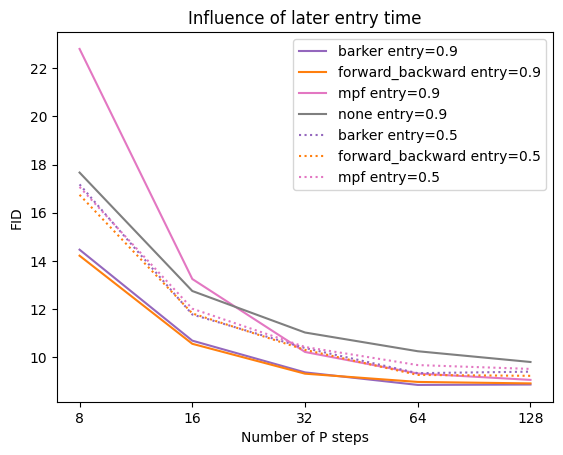

In [7]:
# Group by 'corrector' and plot
df = df_full
# Filter by corrector and step size
df = df[False |
        (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 1.) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 1.) |
        False
]
# Filter by number of corrector steps
df_1 = df[(df['num_cstep'] == 1) & (df['entry_time'] == .9)]
# Filter by entry time

for corrector, group in df_1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} entry=0.9', 
             color=style['corrector_colors'][corrector])

# Filter by entry time
df_2 = df[(df['num_cstep'] == 1) & (df['entry_time'] == .5)]

for corrector, group in df_2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} entry=0.5', 
             color=style['corrector_colors'][corrector], linestyle=':')

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.title('Influence of later entry time')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

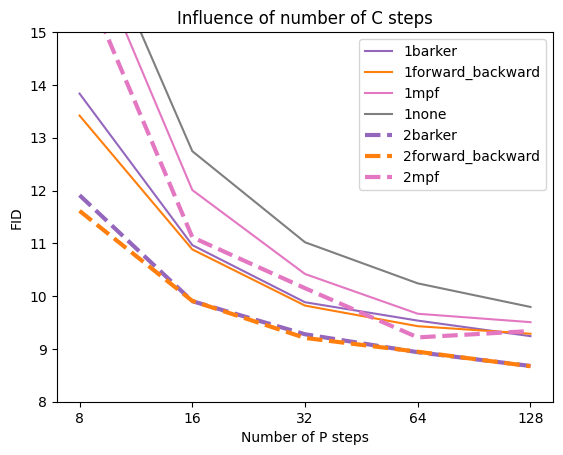

In [8]:
# Group by 'corrector' and plot
df = df_full
# Filter by corrector and step size
df = df[False |
        (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) & (df['entry_time'] == .5) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == .5) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == .5) & (df['entry_time'] == .9) |
        False
]
# Filter by number of corrector steps
df_1 = df[(df['num_cstep'] == 1)]
# Filter by entry time

for corrector, group in df_1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'1{corrector}', 
             color=style['corrector_colors'][corrector])

# Filter by entry time
df_2 = df[(df['num_cstep'] == 2)]

for corrector, group in df_2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'2{corrector}', 
             color=style['corrector_colors'][corrector], linestyle='--', linewidth=3)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((8,15))
plt.title('Influence of number of C steps')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

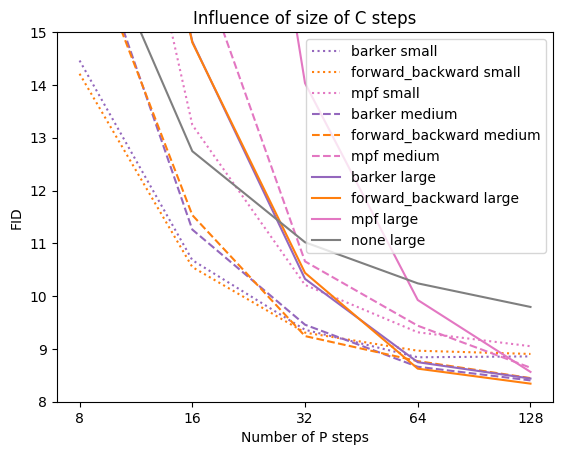

In [9]:
# Group by 'corrector' and plot
df = df_full
df = df[(df['num_cstep'] == 1)]

mpf_entry = .9

# Filter by corrector and step size
df1 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} small', 
             color=style['corrector_colors'][corrector], linestyle=":"#alpha=.5
    )

# Filter by corrector and step size
df2 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .02) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} medium', 
             color=style['corrector_colors'][corrector], linestyle="--"#alpha=.75
            )

# Filter by corrector and step size
df3 = df[False |
        (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .04) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 4.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 4.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df3.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} large', 
             color=style['corrector_colors'][corrector], alpha=1.)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((8, 15))
plt.title('Influence of size of C steps')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

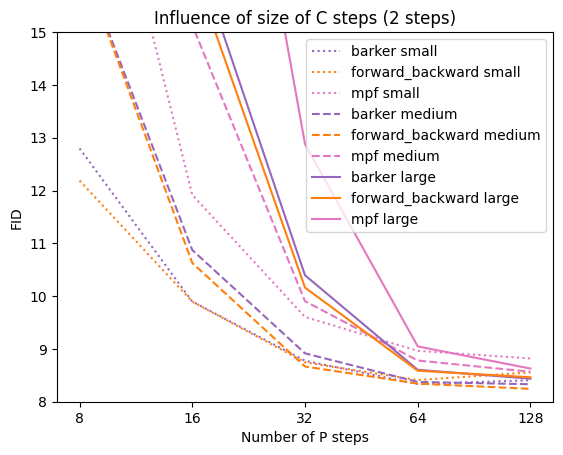

In [10]:
# Group by 'corrector' and plot
df = df_full
df = df[(df['num_cstep'] == 2)]

mpf_entry = .9

# Filter by corrector and step size
df1 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} small', 
             color=style['corrector_colors'][corrector], linestyle=":"#alpha=.5
    )

# Filter by corrector and step size
df2 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .02) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} medium', 
             color=style['corrector_colors'][corrector], linestyle="--"#alpha=.75
            )

# Filter by corrector and step size
df3 = df[False |
        (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .04) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 4.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 4.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df3.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} large', 
             color=style['corrector_colors'][corrector], alpha=1.)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((8, 15))
plt.title('Influence of size of C steps (2 steps)')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

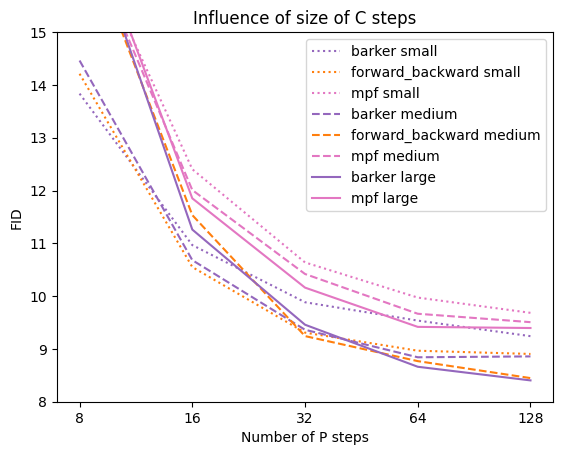

In [11]:
# Group by 'corrector' and plot
df = df_full
df = df[(df['num_cstep'] == 1)]

mpf_entry = .5

# Filter by corrector and step size
df1 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .005) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == .5) & (df['entry_time'] == .9) |
        (df['corrector'] == 'mpf_full') & (df['cstep_size'] == .005) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker_full') & (df['cstep_size'] == .005) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df1.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} small', 
             color=style['corrector_colors'][corrector], linestyle=":"#alpha=.5
    )

# Filter by corrector and step size
df2 = df[False |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .01) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 1.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'mpf_full') & (df['cstep_size'] == .01) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker_full') & (df['cstep_size'] == .01) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df2.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} medium', 
             color=style['corrector_colors'][corrector], linestyle="--"#alpha=.75
            )

# Filter by corrector and step size
df3 = df[False |
        # (df['corrector'] == 'none') |
        (df['corrector'] == 'mpf') & (df['cstep_size'] == .02) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker') & (df['cstep_size'] == 2.) & (df['entry_time'] == .9) |
        (df['corrector'] == 'mpf_full') & (df['cstep_size'] == .02) & (df['entry_time'] == mpf_entry) |
        (df['corrector'] == 'barker_full') & (df['cstep_size'] == .02) & (df['entry_time'] == .9) |
        (df['corrector'] == 'forward_backward') & (df['cstep_size'] == 5.) & (df['entry_time'] == .9) |
        False
]

for corrector, group in df3.groupby('corrector'):
    plt.plot(group['num_pstep'], group['fid'], label=f'{corrector} large', 
             color=style['corrector_colors'][corrector], alpha=1.)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((8, 15))
plt.title('Influence of size of C steps')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
# plt.gca().get_xaxis().set_minor_formatter(ticker.ScalarFormatter())
plt.legend()
plt.show()

# Update: Gibbs results

In [8]:
df_gibbs = pd.read_csv('gibbs_results_11_14.csv')
# Display the first few rows to check the data
print(df_gibbs.head())

  method  num_cstep  entry_time  cstep_size  num_pstep corrector        fid  \
0  euler          1         0.9           0          8     gibbs  13.712424   
1  euler          1         0.9           0          8     gibbs  12.204210   
2  euler          1         0.9           0          8     gibbs  10.976541   
3  euler          1         0.9           0          8     gibbs  10.293639   
4  euler          1         0.9           0          8     gibbs  10.099010   

      k  
0   1.0  
1   2.0  
2   4.0  
3   8.0  
4  16.0  


In [9]:
df_gibbs_random = pd.read_csv('random_gibbs_results_11_28.csv')
df_gibbs_random["corrector"] = df_gibbs_random["corrector"].replace("gibbs","gibbs_temp")
# df_gibbs_random

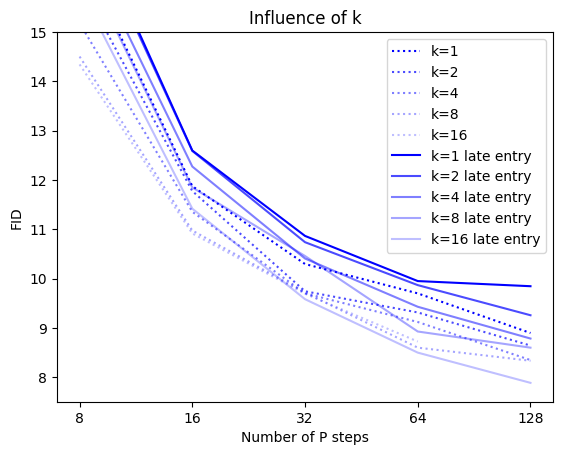

In [10]:
# Group by 'corrector' and plot
df = df_gibbs_random

corrector = 'gibbs_uninformed'
entry = .9

# Filter by corrector and step size
df1 = df[False |
         ((df['corrector'] == corrector) & (df['entry_time'] == entry))
]

for k, group in df1.groupby('k'):
    # print(group)
    plt.plot(group['num_pstep'], group['fid'], label=f'k={k}', 
             color="blue", linestyle=":", alpha=(1/k)**0.5
    )

entry = .5

# Filter by corrector and step size
df1 = df[False |
        ((df['corrector'] == corrector) & (df['entry_time'] == entry))
]

for k, group in df1.groupby('k'):
    plt.plot(group['num_pstep'], group['fid'], label=f'k={k} late entry', 
             color="blue", alpha=(1/k)**0.5
    )


plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((7.5, 15))
plt.title('Influence of k')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()

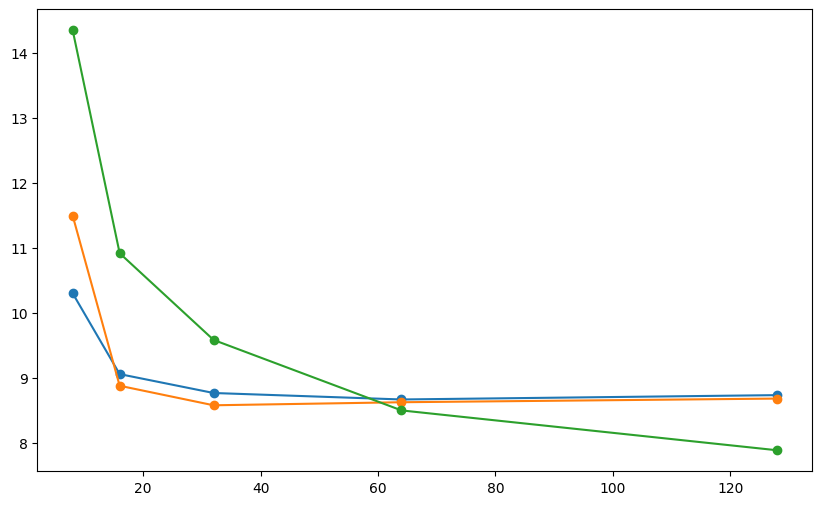

In [12]:
# Group by `corrector` and `num_pstep`, then find the minimum `fid`
best_fid = df.groupby(['corrector', 'num_pstep'])['fid'].min().reset_index()

# Create a plot for each corrector
plt.figure(figsize=(10, 6))
for corrector in best_fid['corrector'].dropna().unique():
    subset = best_fid[best_fid['corrector'] == corrector]
    plt.plot(subset['num_pstep'], subset['fid'], marker='o', label=corrector)

# Full results (Informed vs. Uninformed vs. k-Gibbs)

In [75]:
type(df)

pandas.core.frame.DataFrame

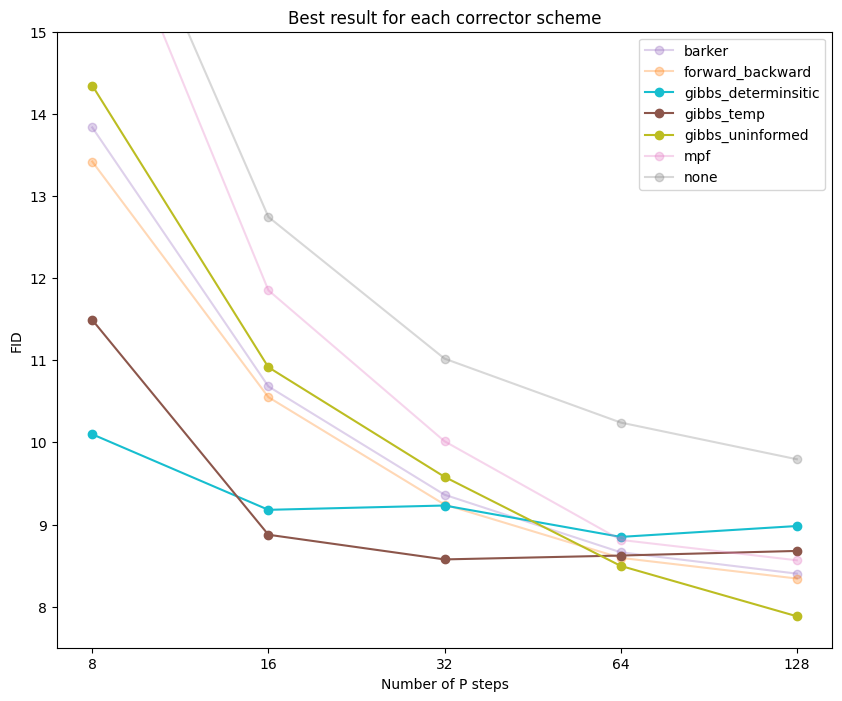

In [19]:
df = df_full
df = pd.concat([df, df_gibbs, df_gibbs_random])
df = df[(df['num_cstep'] == 1)]

best_fid = df.groupby(['corrector', 'num_pstep'])['fid'].min().reset_index()

plt.figure(figsize=(10, 8))
for corrector in best_fid['corrector'].dropna().unique():

    if corrector == "gibbs_mpf":
        continue

    label = "gibbs_determinsitic" if corrector == "gibbs" else corrector
    # alpha = 1.0
    alpha = 0.3 if "gibbs" not in corrector else 1.0
    
    subset = best_fid[best_fid['corrector'] == corrector]
    plt.plot(subset['num_pstep'], subset['fid'], marker='o', label=label, color=style['corrector_colors'][corrector],
             alpha=alpha)

plt.xlabel('Number of P steps')
plt.ylabel('FID')
plt.ylim((7.5, 15))
plt.title('Best result for each corrector scheme')
plt.xscale('log')
plt.xticks([8, 16, 32, 64, 128])
plt.gca().get_xaxis().set_major_formatter(ticker.ScalarFormatter())
plt.minorticks_off()
plt.legend()
plt.show()